In [1]:
import pandas as pd
import numpy as np
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
from typing import Union
import warnings
from datetime import datetime
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from neuralforecast.core import NeuralForecast
from neuralforecast.models import PatchTST, TFT, DilatedRNN, VanillaTransformer 
from neuralforecast.losses.pytorch import MAE, MSE
import argparse
import sys
import os
from Data.Data_Generator_ILI_HHS_TimeSplit import prepare_ILI_data
from Utils import drop_last_n_samples, splitter
import contextlib
import io
import pytorch_lightning as pl
import logging
import warnings
from pathlib import Path
import os
os.environ["NIXTLA_ID_AS_COL"] = "True"


In [2]:

def load_weekly_deaths_nixtla(csv_path: str | Path, impute_small_counts: bool = False) -> pd.DataFrame:
    df = (pd.read_csv(csv_path)
            .rename(columns={'Geography': 'unique_id',
                             'Date': 'ds',
                             'Weekly Deaths': 'y'}))

    # Parse the date column first so we can sort chronologically
    df['ds'] = pd.to_datetime(df['ds'], format='%b %d %Y')
    # Optionally impute the CDC “Counts 1‑9” mask
    if impute_small_counts:
        df['y'] = df['y'].replace({'Counts 1-9': 5})
    else:
        df['y'] = df['y'].replace({'Counts 1-9': pd.NA})
    df['y'] = pd.to_numeric(df['y'], errors='coerce')
    # Sort and create the integer index (1‑based) per region
    df = df.sort_values(['unique_id', 'ds'])
    df['ds'] = df.groupby('unique_id').cumcount().add(1)  # 1,2,3,…

    return df[['unique_id', 'ds', 'y']].reset_index(drop=True)

path = "Covid19_weekly_deaths_all_regions.csv"
COVID19_df = load_weekly_deaths_nixtla(path, impute_small_counts=False)
COVID19_df

,unique_id,ds,y
0,Region 1,1,0
1,Region 1,2,0
2,Region 1,3,0
3,Region 1,4,0
4,Region 1,5,0
...,...,...,...
3064,United States,275,346
3065,United States,276,358
3066,United States,277,284
3067,United States,278,210


In [3]:
from datasetsforecast.m4 import M4
data, _,  S_df = M4.load(directory='./data', group='Weekly')
# Function to apply Min-Max normalization
def group_cumcount(group):
    group['ds'] = group.groupby('unique_id').cumcount().add(1)
    return group
# Apply normalization group by group
M4_weekly_df = data.groupby('unique_id').apply(group_cumcount)
M4_weekly_df

/tmp/ipykernel_623082/127099126.py:8: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  M4_weekly_df = data.groupby('unique_id').apply(group_cumcount)


,unique_id,ds,y
0,W1,1,1089.20
1,W1,2,1078.91
2,W1,3,1079.88
3,W1,4,1063.58
4,W1,5,1060.61
...,...,...,...
371574,W99,2292,14864.72
371575,W99,2293,14893.35
371576,W99,2294,14811.60
371577,W99,2295,14898.23


In [4]:
import pandas as pd
from datasetsforecast.long_horizon import LongHorizon
data, X_df, S_df = LongHorizon.load(directory='./data', group='TrafficL')
def group_cumcount(group):
    group['ds'] = group.groupby('unique_id').cumcount().add(1)
    return group

TrafficL_df = data.groupby('unique_id').apply(group_cumcount)
TrafficL_df

/tmp/ipykernel_623082/1052221853.py:9: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  TrafficL_df = data.groupby('unique_id').apply(group_cumcount)


         unique_id     ds         y
0                0      1 -0.711224
1                0      2 -0.672014
2                0      3 -0.724294
3                0      4 -0.725928
4                0      5 -0.721027
...            ...    ...       ...
15122923        OT  17540  0.765917
15122924        OT  17541  0.389237
15122925        OT  17542  0.172360
15122926        OT  17543 -0.090175
15122927        OT  17544 -0.495391

[15122928 rows x 3 columns]


In [5]:
path_to_data = "Data/ILINet.csv"
test_size = 0.2
train_df, test_df, df, data, number_of_time_series, length_time_series, forecasting_horizon, number_of_samples_in_test = prepare_ILI_data(path_to_data, test_size)
train_df

/sfs/weka/scratch/jrp5td/Geoff_test_2/Data/Data_Generator_ILI_HHS_TimeSplit.py:22: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data = data.fillna(data.mean())
/sfs/weka/scratch/jrp5td/Geoff_test_2/Data/Data_Generator_ILI_HHS_TimeSplit.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'y'] = df['y'].astype(float)


,ds,unique_id,y
0,1,Region 1,0.905434
1,2,Region 1,1.012450
2,3,Region 1,0.835424
3,4,Region 1,1.093970
4,5,Region 1,0.995161
...,...,...,...
7995,796,Region 9,0.837133
7996,797,Region 9,0.736869
7997,798,Region 9,0.792926
7998,799,Region 9,0.778513


  0%|          | 0/1 [00:00<?, ?it/s][rank: 0] Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


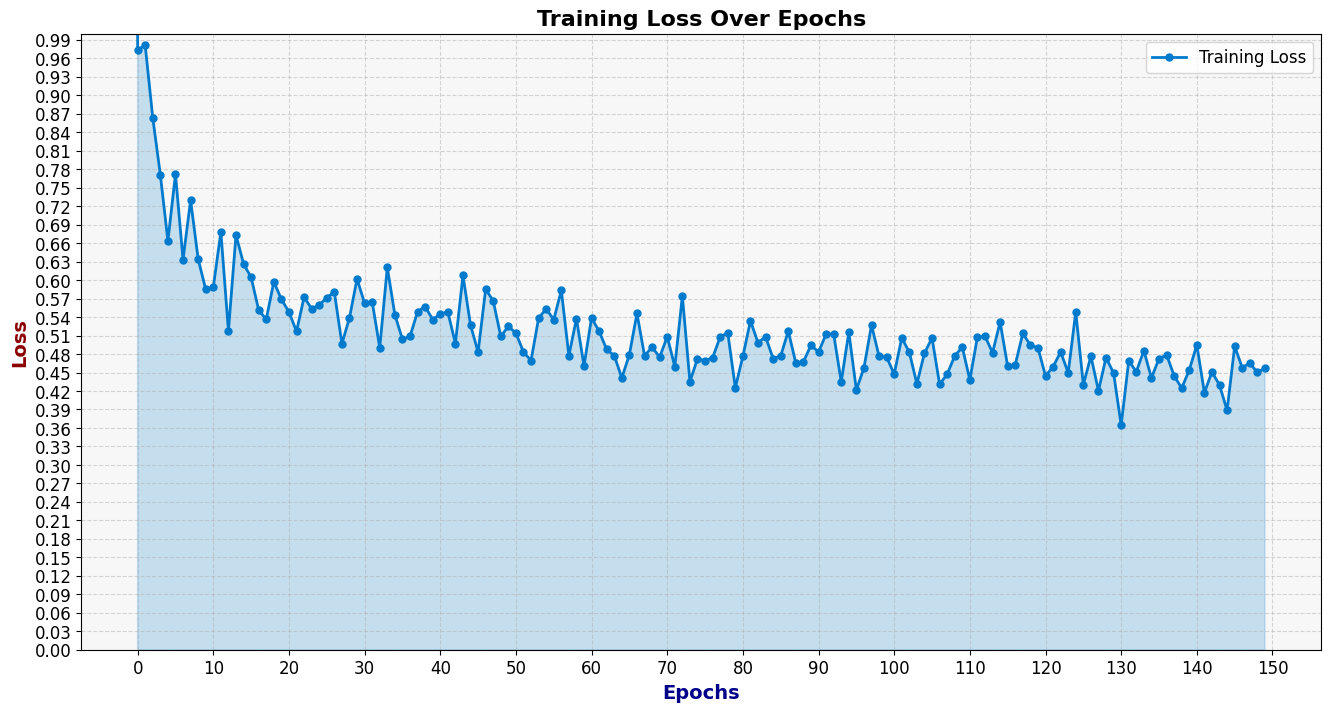

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


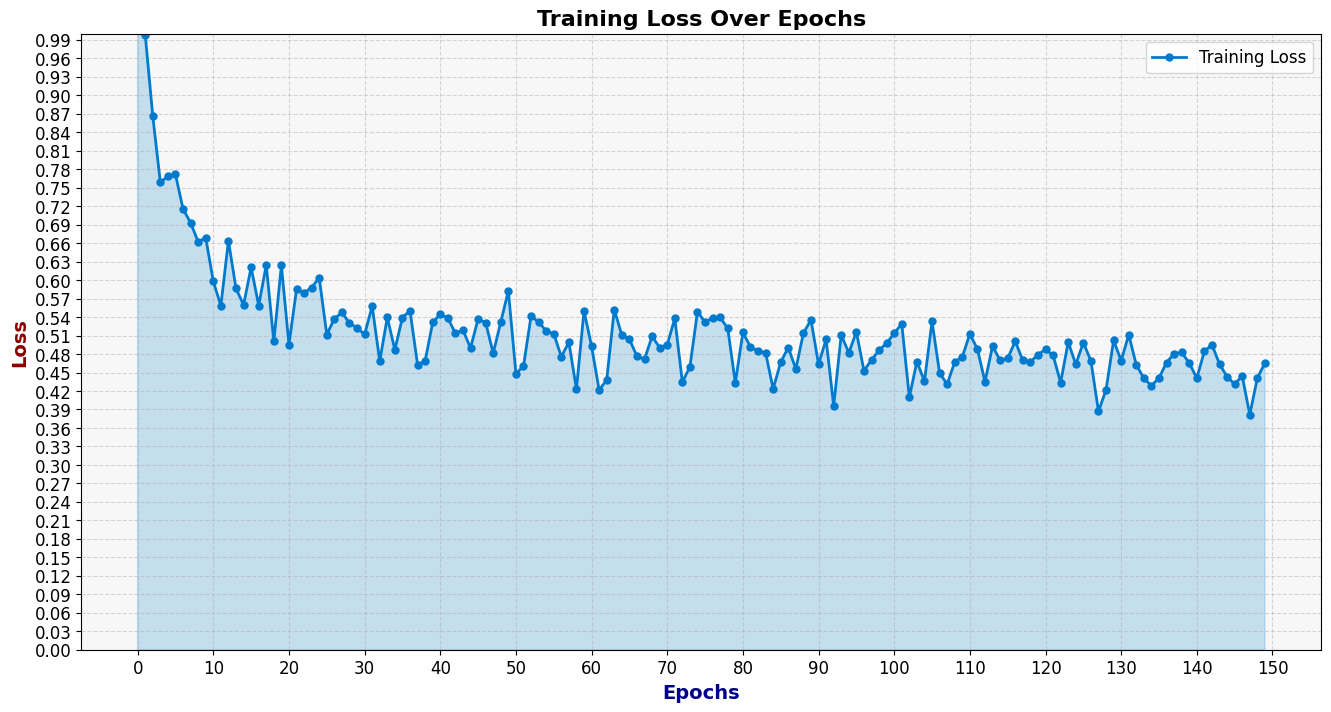

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


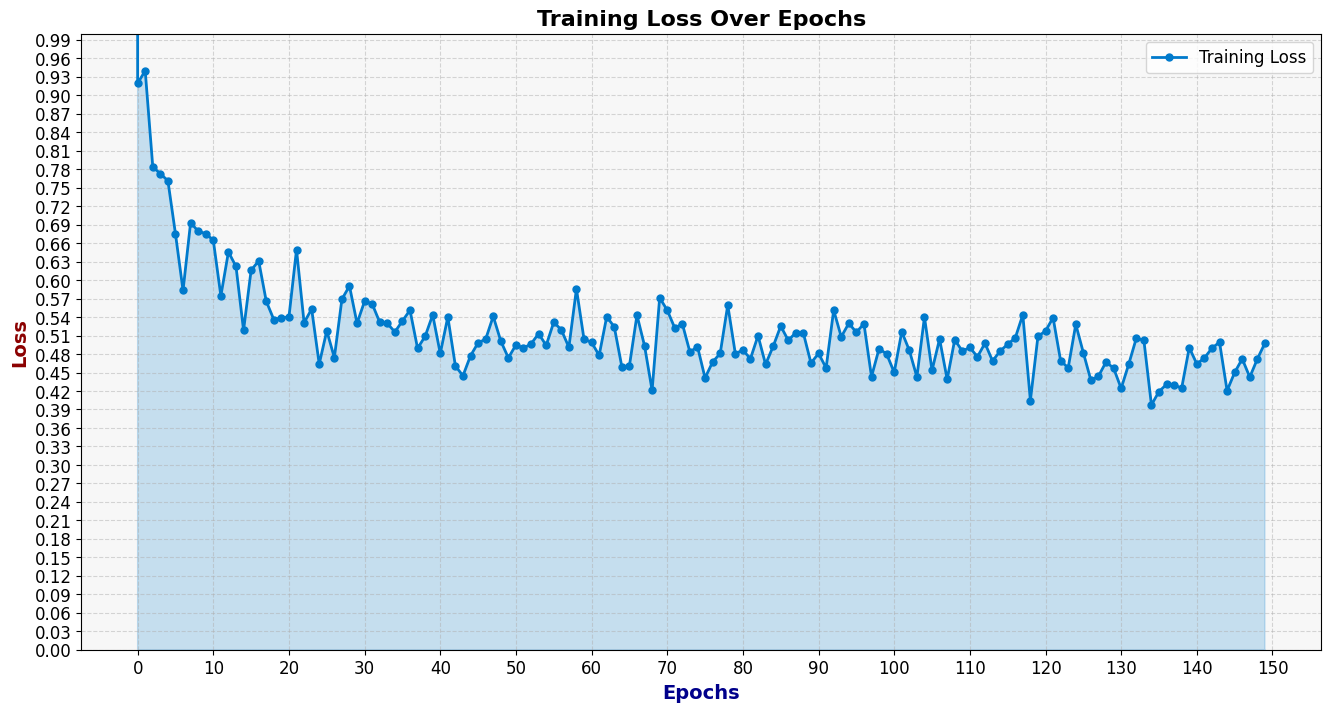

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


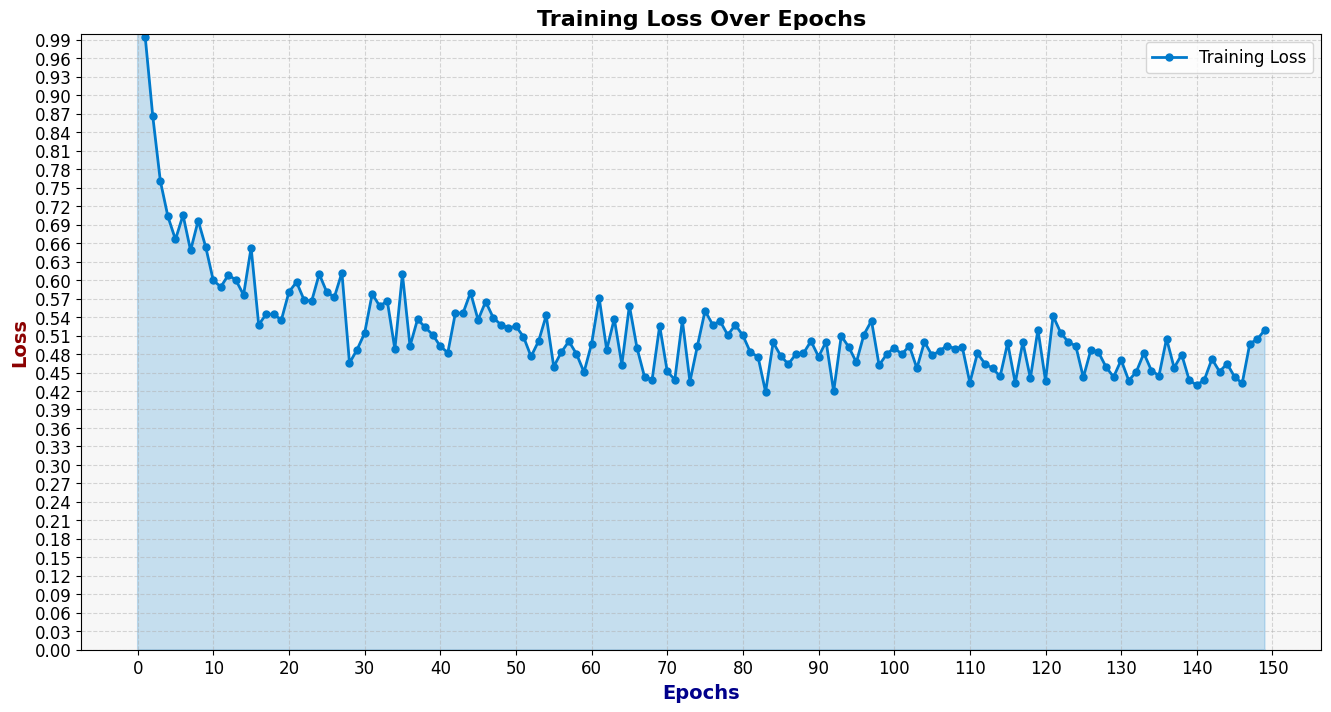

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


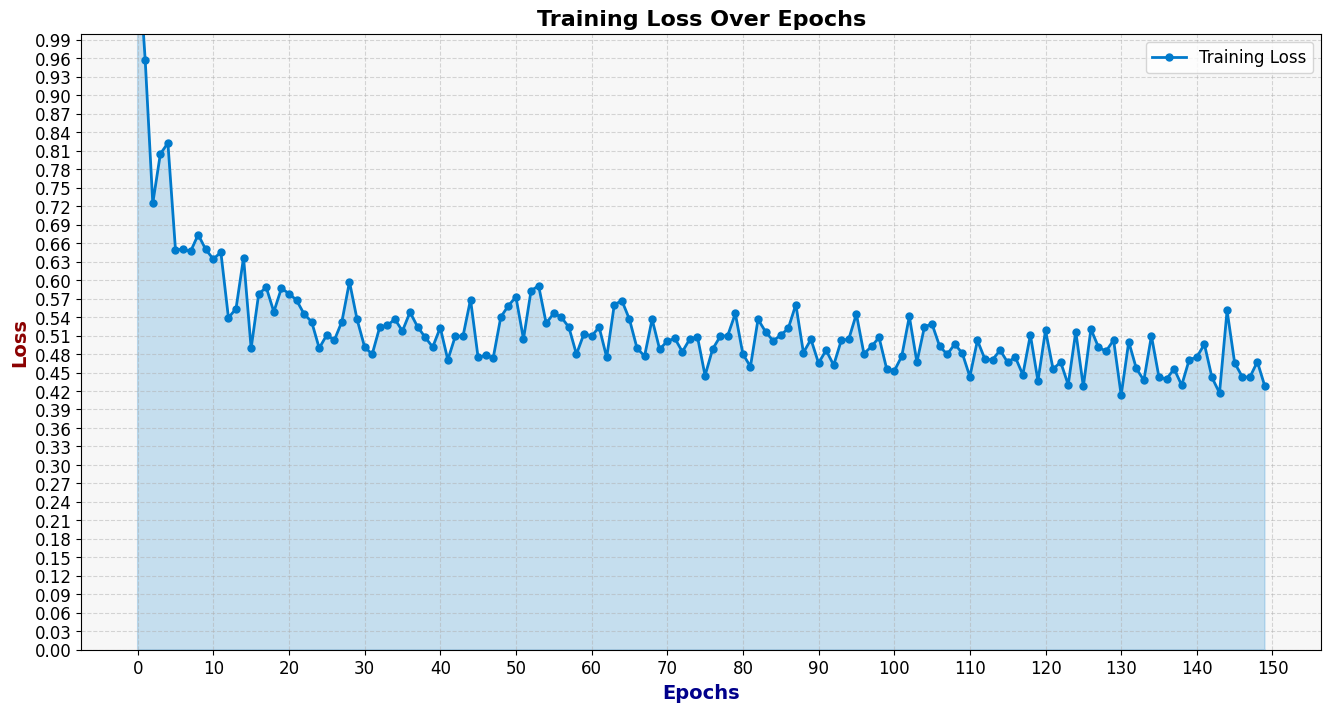

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.


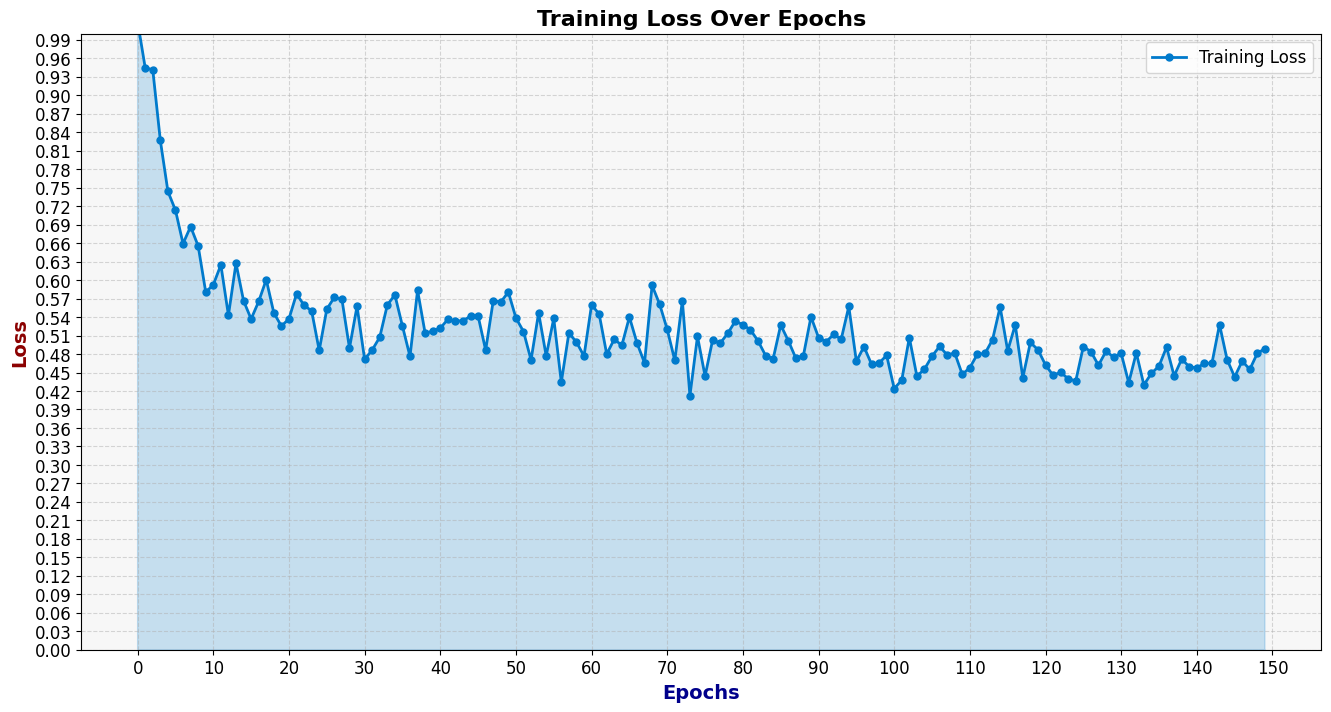

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


100%|██████████| 1/1 [00:21<00:00, 21.52s/it]


Evaluation ended.
    Dataset: ILI
    Model: PatchTST
    Target_series: % WEIGHTED ILI
    Feature: % WEIGHTED ILI
    Normalization: None

    Splitting_strategy: Time-based
    Validation: No
    Samples in one time series: 1000
    Samples in test part: 200
    Number of time series: 10
    Frequency: '1W'

    forecasting_horizon: 4
    Look back size: 52
    Step size: 1
    max_steps: 150
    loss: "MSE"
    learning_rate: 0.0005
    batch_size: 10
    scaler_type: None
    seed_neuralforecast: 6

    training loss (MSE): 0.48871
    ***RESULTS h1***
    MSE:    0.13529
    MAE:    0.21666
    SMAPE:  8.87621
    NNSE:   0.94632
    R²:     0.94328

    ***RESULTS h2***
    MSE:    0.34500
    MAE:    0.34278
    SMAPE:  13.61102
    NNSE:   0.87362
    R²:     0.85534

    ***RESULTS h3***
    MSE:    0.51756
    MAE:    0.43821
    SMAPE:  17.76987
    NNSE:   0.82169
    R²:     0.78299

    ***RESULTS h4***
    MSE:    0.66651
    MAE:    0.50399
    SMAPE:  20.69825
    NN

In [18]:

for seed in [1,2,3,4,5,6]:
    
    model = "PatchTST"
    forecasting_horizon = 4
    look_back_size=52
    batch_size = number_of_time_series
    learning_rate=5e-4
    max_steps = 150
    path_to_model = f"{model}/{model}_TimeSplit.py"
    scaler_type = None
    step_size=1 
    window_retrain = 200
    
    path_to_results = f"{model}/TB_h4_lr_{learning_rate}_epoch_{max_steps}_lbs_{look_back_size}_window_retrain_{window_retrain}"
    if not os.path.exists(path_to_results):
        os.makedirs(path_to_results)
        
    all_preds = pd.DataFrame()
    for s, index_splitter_train_test_data in enumerate(tqdm(range(number_of_samples_in_test, 0, -window_retrain))):
        
        train_df, _ = splitter(df, 'unique_id', index_splitter_train_test_data)
        number_of_samples_in_train = len(train_df)/number_of_time_series

        # Model configuration
        models = [PatchTST (h=forecasting_horizon, 
                      input_size=look_back_size, 
                      max_steps=max_steps, 
                      learning_rate=learning_rate, 
                      loss=MSE(), random_seed=seed, 
                      scaler_type=scaler_type, 
                      batch_size=batch_size, 
                      step_size=step_size,
                      windows_batch_size=int(batch_size*(number_of_samples_in_train-forecasting_horizon-look_back_size+1)/4)
                     )]
        nf = NeuralForecast(models=models, freq=1, local_scaler_type=scaler_type)
        
        
        nf.fit(M4_weekly_df, verbose=True, val_size=0) #COVID19_df, TrafficL_df, M4_weekly_df
        nf.fit(train_df, verbose=True, val_size=0)

        # Extract training loss
        training_loss = getattr(nf.models[0], "train_trajectories", [])
        epochs = [epoch for epoch, loss in training_loss]
        loss_values = [loss for epoch, loss in training_loss]

        # Plot and save training loss
        plt.figure(figsize=(16, 8))
        plt.plot(epochs, loss_values, marker='o', linestyle='-', color='#007acc', linewidth=2, markersize=5, label='Training Loss')
        plt.xlabel("Epochs", fontsize=14, fontweight='bold', color='darkblue')
        plt.ylabel("Loss", fontsize=14, fontweight='bold', color='darkred')
        plt.title("Training Loss Over Epochs", fontsize=16, fontweight='bold', color='black')
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.gca().set_facecolor("#f7f7f7")
        plt.fill_between(epochs, loss_values, alpha=0.2, color='#007acc')
        plt.xticks(fontsize=12, color='black')
        plt.yticks(fontsize=12, color='black')
        ax = plt.gca()
        ax.set_ylim([0, 1])
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.03))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
        plt.legend(fontsize=12, loc='upper right')
        plt.savefig(f"{path_to_results}/training_loss_plot_TB_h{forecasting_horizon}_s{seed}_{s}.png", dpi=300, bbox_inches='tight')
        plt.show()

        trainer = pl.Trainer(logger=False)
        logging.getLogger().setLevel(logging.ERROR)
        logging.getLogger("pytorch_lightning").setLevel(logging.CRITICAL)
        warnings.filterwarnings("ignore")

        def transform_df(df):
            first_ds_values = df.groupby("unique_id")["ds"].first().reset_index()
            first_ds_values.rename(columns={"ds": "first_ds"}, inplace=True)
            df_pivot = df.pivot(index='unique_id', columns='ds', values=model)
            df_pivot.columns = ['y_hat_1', 'y_hat_2', 'y_hat_3', 'y_hat_4']
            df_pivot = df_pivot.reset_index()
            df_pivot = df_pivot.merge(first_ds_values, on="unique_id")
            column_order = ["first_ds", "unique_id", 'y_hat_1', 'y_hat_2', 'y_hat_3', 'y_hat_4']
            df_pivot = df_pivot[column_order]
            return df_pivot

        print("Starting evaluation ....")
        for idx, i in enumerate(tqdm(range(index_splitter_train_test_data, index_splitter_train_test_data-window_retrain, -1))):
            _, data_batch_part = splitter(df, 'unique_id', i + look_back_size)
            data_batch_part = drop_last_n_samples(data_batch_part, 'unique_id', i)
            preds = nf.predict(data_batch_part)
            preds = preds.reset_index(drop=True)
            transformed_df = transform_df(preds)
            all_preds = pd.concat([all_preds, transformed_df], ignore_index=True)
        print("Evaluation ended.")

        def shift_up_by_group(df, group_col, columns_to_shift, shift_by, fill_value=0):
            shifted_groups = []
            unique_groups = df[group_col].unique()
            for grp_value in unique_groups:
                group_data = df[df[group_col] == grp_value].copy()
                group_data[columns_to_shift] = group_data[columns_to_shift].shift(shift_by)
                shifted_groups.append(group_data)
            df_shifted = pd.concat(shifted_groups, ignore_index=True)
            return df_shifted[columns_to_shift]


    all_preds = all_preds.sort_values(by=['unique_id', 'first_ds'], ascending=[True, True])
    test_df = test_df.sort_values(by=['unique_id', 'ds'], ascending=[True, True])
    results_df = all_preds.copy()
    results_df = results_df.reset_index(drop=True)
    test_df    = test_df.reset_index(drop=True)
    results_df['y_actual_1'] = test_df['y'].values
    results_df['y_actual_2'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-1, fill_value=0)
    results_df['y_actual_3'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-2, fill_value=0)
    results_df['y_actual_4'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-3, fill_value=0)


    def results_calculator(df, group_col, traget_y, predicted_y, shift_by, number_of_time_series, number_of_samples_in_test):
        filtered_df = df[['first_ds', 'unique_id', traget_y, predicted_y]]
        shifted_groups = []
        unique_groups = df[group_col].unique()
        for grp_value in unique_groups:
            group_data = df[df[group_col] == grp_value].copy()
            group_data.drop(group_data.tail(shift_by).index, inplace=True)
            shifted_groups.append(group_data)
        df_shifted = pd.concat(shifted_groups, ignore_index=True)

        Y_ACTUAL = df_shifted[traget_y].values.reshape(number_of_time_series, number_of_samples_in_test-shift_by)
        Y_HAT = df_shifted[predicted_y].values.reshape(number_of_time_series, number_of_samples_in_test-shift_by)

        mae = np.mean(np.abs(Y_ACTUAL - Y_HAT))
        mse = np.mean(np.square(Y_ACTUAL - Y_HAT))
        nnse = 1 / (2 - (1 - np.sum(np.square(Y_ACTUAL - Y_HAT)) / np.sum(np.square(Y_ACTUAL - np.mean(Y_ACTUAL)))))
        r2 = 1 - (np.sum(np.square(Y_ACTUAL - Y_HAT)) / np.sum(np.square(Y_ACTUAL - np.mean(Y_ACTUAL))))
        smape = 100 * np.mean(2 * np.abs(Y_HAT - Y_ACTUAL) / (np.abs(Y_ACTUAL) + np.abs(Y_HAT) + 1e-8))

        return mae, mse, nnse, smape, r2


    mae_1, mse_1, nnse_1, smape_1, r2_1 = results_calculator(results_df, 'unique_id', 'y_actual_1', 'y_hat_1', 0, number_of_time_series, number_of_samples_in_test)
    mae_2, mse_2, nnse_2, smape_2, r2_2 = results_calculator(results_df, 'unique_id', 'y_actual_2', 'y_hat_2', 1, number_of_time_series, number_of_samples_in_test)
    mae_3, mse_3, nnse_3, smape_3, r2_3 = results_calculator(results_df, 'unique_id', 'y_actual_3', 'y_hat_3', 2, number_of_time_series, number_of_samples_in_test)
    mae_4, mse_4, nnse_4, smape_4, r2_4 = results_calculator(results_df, 'unique_id', 'y_actual_4', 'y_hat_4', 3, number_of_time_series, number_of_samples_in_test)

    avg_mse = (mse_1+mse_2+mse_3+mse_4)/4

    # Save results
    config_text = f"""\
    Dataset: ILI
    Model: {model}
    Target_series: % WEIGHTED ILI
    Feature: % WEIGHTED ILI
    Normalization: None

    Splitting_strategy: Time-based
    Validation: No
    Samples in one time series: {length_time_series}
    Samples in test part: {number_of_samples_in_test}
    Number of time series: {number_of_time_series}
    Frequency: '1W'

    forecasting_horizon: {forecasting_horizon}
    Look back size: {look_back_size}
    Step size: {step_size}
    max_steps: {max_steps}
    loss: "MSE"
    learning_rate: {learning_rate}
    batch_size: {batch_size}
    scaler_type: {scaler_type}
    seed_neuralforecast: {seed}

    training loss (MSE): {loss_values[-1]:.5f}
    ***RESULTS h1***
    MSE:    {mse_1:.5f}
    MAE:    {mae_1:.5f}
    SMAPE:  {smape_1:.5f}
    NNSE:   {nnse_1:.5f}
    R²:     {r2_1:.5f}

    ***RESULTS h2***
    MSE:    {mse_2:.5f}
    MAE:    {mae_2:.5f}
    SMAPE:  {smape_2:.5f}
    NNSE:   {nnse_2:.5f}
    R²:     {r2_2:.5f}

    ***RESULTS h3***
    MSE:    {mse_3:.5f}
    MAE:    {mae_3:.5f}
    SMAPE:  {smape_3:.5f}
    NNSE:   {nnse_3:.5f}
    R²:     {r2_3:.5f}

    ***RESULTS h4***
    MSE:    {mse_4:.5f}
    MAE:    {mae_4:.5f}
    SMAPE:  {smape_4:.5f}
    NNSE:   {nnse_4:.5f}
    R²:     {r2_4:.5f}

    ***Average MSE***
    avg_mse: {avg_mse}
    """

    with open(f"{path_to_results}/Results_TB_h{forecasting_horizon}_s{seed}.txt", "w") as file:
        file.write(config_text)

    print(config_text)


In [19]:
import os
import glob
import statistics
import re

def parse_metrics_from_file(filepath):
    """
    Parse the desired metrics from a single results file.
    Returns a dictionary with the following structure:
    {
      "training_loss": float,
      "avg_mse": float,
      "h1": {"MSE": float, "MAE": float, "SMAPE": float, "NNSE": float, "R2": float},
      "h2": {...},
      "h3": {...},
      "h4": {...}
    }
    If something is not found, returns None for that field.
    """

    # Initialize the dict with None (or any default) for each metric
    metrics_dict = {
        "training_loss": None,
        "avg_mse": None,
        "h1": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h2": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h3": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h4": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
    }

    # Regex patterns to extract numbers (floats). 
    # We'll look for lines like: "training loss (MSE): 0.39443" or "MSE:    0.15226"
    # Adjust the patterns if your file format changes.
    pattern_training_loss = re.compile(r"training loss.*:\s*([0-9.]+)")
    pattern_avg_mse = re.compile(r"avg_mse:\s*([0-9.]+)")

    # For lines like "***RESULTS h1***" we capture h1
    # For lines like "MSE:\s*([0-9.]+)"
    pattern_horizon = re.compile(r"\*\*\*RESULTS\s+(h[0-9]+)\*\*\*")
    pattern_key_value = re.compile(r"(MSE|MAE|SMAPE|NNSE|R²?):\s*([0-9.]+)")

    current_horizon = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            # 1) Training Loss
            train_match = pattern_training_loss.search(line)
            if train_match:
                metrics_dict["training_loss"] = float(train_match.group(1))
                continue

            # 2) Average MSE
            avg_mse_match = pattern_avg_mse.search(line)
            if avg_mse_match:
                metrics_dict["avg_mse"] = float(avg_mse_match.group(1))
                continue

            # 3) Detect horizon header (e.g. ***RESULTS h1***)
            horizon_match = pattern_horizon.search(line)
            if horizon_match:
                current_horizon = horizon_match.group(1)  # e.g. 'h1', 'h2', etc.
                continue

            # 4) Inside horizon block, parse lines like "MSE:    0.15226"
            if current_horizon is not None:
                kv_match = pattern_key_value.search(line)
                if kv_match:
                    metric_name = kv_match.group(1)  # e.g. 'MSE'
                    metric_value = float(kv_match.group(2))

                    # Correct potential mismatch 'R²' vs 'R2' dictionary key
                    if metric_name.startswith('R'):
                        metric_name = "R2"

                    metrics_dict[current_horizon][metric_name] = metric_value

    return metrics_dict


def main(results_folder="path/to/results_folder"):
    """
    1. Collect all .txt files (or any extension) from the specified results_folder
    2. Parse metrics for each file
    3. Aggregate all metrics (mean, std)
    """

    # A structure to accumulate metric values across all files
    # We'll store lists, then compute mean and std afterwards
    all_metrics = {
        "training_loss": [],
        "avg_mse": [],
        "h1": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h2": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h3": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h4": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
    }

    # Modify the glob pattern as needed (e.g. *.txt, *.log, etc.)
    file_list = glob.glob(os.path.join(results_folder, "*.txt"))

    for file_path in file_list:
        parsed = parse_metrics_from_file(file_path)

        # Append each metric if found
        if parsed["training_loss"] is not None:
            all_metrics["training_loss"].append(parsed["training_loss"])
        if parsed["avg_mse"] is not None:
            all_metrics["avg_mse"].append(parsed["avg_mse"])

        for horizon in ["h1", "h2", "h3", "h4"]:
            for mkey in ["MSE", "MAE", "SMAPE", "NNSE", "R2"]:
                val = parsed[horizon].get(mkey, None)
                if val is not None:
                    all_metrics[horizon][mkey].append(val)

    # Helper to compute mean and sample std
    def mean_std(values):
        if len(values) == 0:
            return (None, None)
        return (statistics.mean(values), statistics.stdev(values))

    # Print aggregated results
    print("===== AGGREGATED RESULTS ACROSS ALL FILES =====")
    # training_loss
    mean_val, std_val = mean_std(all_metrics["training_loss"])
    print(f"Training Loss (MSE): mean={mean_val:.3f}, std={std_val:.3f}")

    # avg_mse
    mean_val, std_val = mean_std(all_metrics["avg_mse"])
    print(f"Average MSE:         mean={mean_val:.3f}, std={std_val:.3f}")

    # For each horizon and each metric
    for horizon in ["h1", "h2", "h3", "h4"]:
        print(f"\n--- {horizon.upper()} ---")
        for metric_name in ["MSE", "MAE", "SMAPE", "NNSE", "R2"]:
            mean_val, std_val = mean_std(all_metrics[horizon][metric_name])
            print(f"{metric_name}: mean={mean_val:.3f}, std={std_val:.3f}")



path_to_results = f"{model}/TB_h4_lr_{learning_rate}_epoch_{max_steps}_lbs_{look_back_size}_window_retrain_{window_retrain}"
main(results_folder=path_to_results)




===== AGGREGATED RESULTS ACROSS ALL FILES =====
Training Loss (MSE): mean=0.476, std=0.033
Average MSE:         mean=0.415, std=0.017

--- H1 ---
MSE: mean=0.130, std=0.005
MAE: mean=0.212, std=0.003
SMAPE: mean=8.549, std=0.237
NNSE: mean=0.948, std=0.002
R2: mean=0.946, std=0.002

--- H2 ---
MSE: mean=0.337, std=0.013
MAE: mean=0.341, std=0.006
SMAPE: mean=13.701, std=0.209
NNSE: mean=0.876, std=0.004
R2: mean=0.859, std=0.006

--- H3 ---
MSE: mean=0.517, std=0.023
MAE: mean=0.437, std=0.007
SMAPE: mean=18.040, std=0.298
NNSE: mean=0.822, std=0.007
R2: mean=0.783, std=0.010

--- H4 ---
MSE: mean=0.677, std=0.033
MAE: mean=0.512, std=0.010
SMAPE: mean=21.556, std=0.759
NNSE: mean=0.779, std=0.008
R2: mean=0.716, std=0.014


### PatchTST-M4
==== AGGREGATED RESULTS ACROSS ALL FILES =====

Average MSE:         mean=0.415, std=0.017

--- H1 ---
MSE: mean=0.130, std=0.005
NNSE: mean=0.948, std=0.002

--- H2 ---
MSE: mean=0.337, std=0.013
NNSE: mean=0.876, std=0.004

--- H3 ---
MSE: mean=0.517, std=0.023
NNSE: mean=0.822, std=0.007

--- H4 ---
MSE: mean=0.677, std=0.033
NNSE: mean=0.779, std=0.008

### PatchTST-COVID19
===== AGGREGATED RESULTS ACROSS ALL FILES =====

Average MSE:         mean=0.419, std=0.018

--- H1 ---
MSE: mean=0.133, std=0.008
NNSE: mean=0.947, std=0.003

--- H2 ---
MSE: mean=0.335, std=0.010
NNSE: mean=0.877, std=0.003

--- H3 ---
MSE: mean=0.523, std=0.026
NNSE: mean=0.820, std=0.007

--- H4 ---
MSE: mean=0.686, std=0.035
NNSE: mean=0.777, std=0.009


### PatchTST-TrafficL
===== AGGREGATED RESULTS ACROSS ALL FILES =====

Average MSE:         mean=0.422, std=0.009

--- H1 ---
MSE: mean=0.131, std=0.006
NNSE: mean=0.948, std=0.002

--- H2 ---
MSE: mean=0.345, std=0.014
NNSE: mean=0.874, std=0.004

--- H3 ---
MSE: mean=0.527, std=0.020
NNSE: mean=0.819, std=0.006

--- H4 ---
MSE: mean=0.684, std=0.005
NNSE: mean=0.777, std=0.001